<a href="https://colab.research.google.com/github/victorealeal/pre-processamento-churn-telecom/blob/main/An%C3%A1lise_segunda_etapa-pr%C3%A9modelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [48]:
df.to_csv('CHURN_TELECON_MOD08_TAREFA_cleaned.csv', index=False)
print('DataFrame salvo como CHURN_TELECON_MOD08_TAREFA_cleaned.csv')

DataFrame salvo como CHURN_TELECON_MOD08_TAREFA_cleaned.csv


In [49]:
df = pd.read_csv('CHURN_TELECON_MOD08_TAREFA_cleaned.csv')
df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [50]:
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2500.00000,2500.000000,2175.000000,2500.000000
mean,0.16080,32.341600,65.607563,2291.882880
std,0.36742,24.626398,29.931520,2265.347752
min,0.00000,0.000000,18.400000,18.800000
25%,0.00000,8.000000,39.500000,402.337500
50%,0.00000,29.000000,71.450000,1405.325000
75%,0.00000,56.000000,90.250000,3867.162500
max,1.00000,72.000000,118.650000,8564.750000


Sim, é possível identificar uma variável com potenciais outliers com base na df.describe()saída. A Total_Pagocoluna se destaca: seu valor máximo (8564,75) é significativamente maior que seu 75º percentil (3867,16). Essa grande diferença sugere fortemente a presença de outliers de alto valor na coluna 'Total_Pago'. As outras colunas numéricas ( Idoso, Tempo_como_Cliente, Pagamento_Mensal) não apresentam discrepâncias tão extremas em suas estatísticas descritivas.

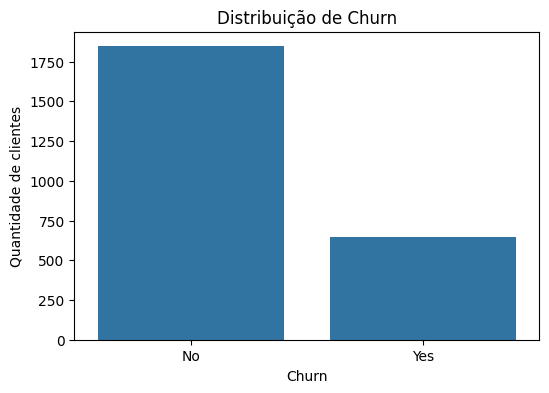

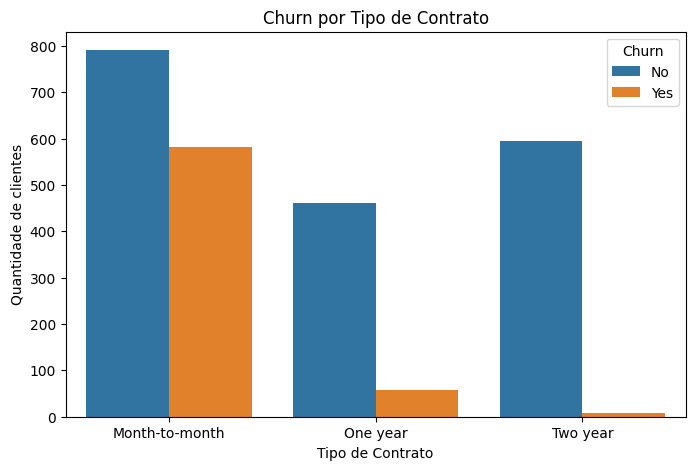

In [51]:
#A variável `Churn` apresenta duas categorias, representando clientes que permaneceram e clientes que deixaram a empresa.
#A distribuição permite observar o equilíbrio da variável preditora e identificar se existe predominância de uma das categorias.

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de clientes')

plt.show()

# Observa-se diferença na distribuição do `Churn` entre os tipos de contrato.
#Clientes com contratos de menor duração apresentam maior concentração de cancelamentos, enquanto contratos mais longos tendem a apresentar menor ocorrência de churn. Essa variável pode ser relevante para compreender a permanência dos clientes.

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Tipo_Contrato', hue='Churn')

plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de clientes')

plt.show()




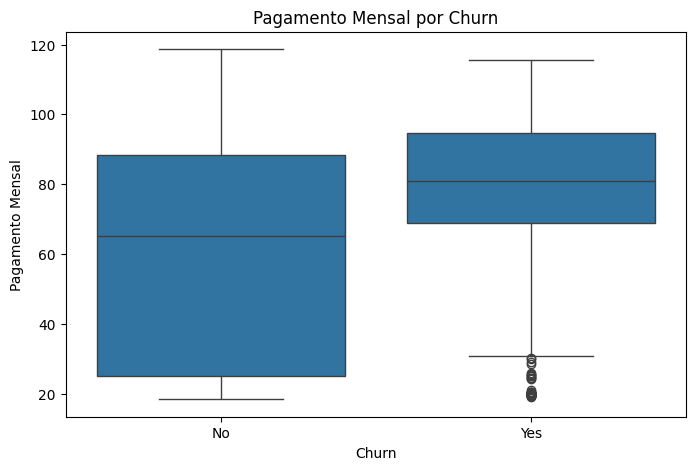

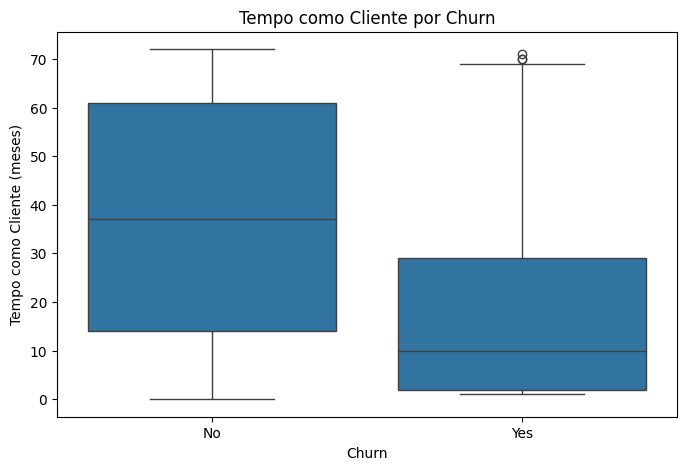

In [52]:
#O gráfico permite comparar a distribuição do `Pagamento_Mensal` entre clientes que permaneceram e clientes que realizaram churn.
#Diferenças nas medianas e na dispersão dos valores podem indicar uma possível relação entre o valor pago mensalmente e a probabilidade de cancelamento.

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='Pagamento_Mensal')

plt.title('Pagamento Mensal por Churn')
plt.xlabel('Churn')
plt.ylabel('Pagamento Mensal')

plt.show()

#O tempo de permanência apresenta diferenças entre os grupos de `Churn`.
#Clientes que permanecem na empresa por períodos menores podem apresentar maior ocorrência de cancelamento, enquanto clientes com maior tempo de relacionamento tendem a apresentar maior permanência.

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='Tempo_como_Cliente')

plt.title('Tempo como Cliente por Churn')
plt.xlabel('Churn')
plt.ylabel('Tempo como Cliente (meses)')

plt.show()

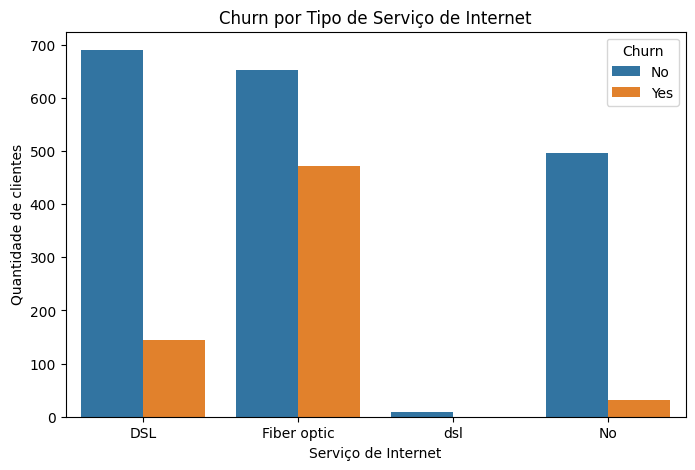

In [53]:
#A distribuição do `Churn` varia de acordo com o tipo de serviço de internet contratado.
#Algumas categorias apresentam maior concentração proporcional de clientes que realizaram churn, indicando que o tipo de serviço pode ser uma variável relevante para análises posteriores.

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Servico_Internet', hue='Churn')

plt.title('Churn por Tipo de Serviço de Internet')
plt.xlabel('Serviço de Internet')
plt.ylabel('Quantidade de clientes')

plt.show()

In [54]:
colunas_binarias = [
    'Genero',
    'Casado',
    'Dependents',
    'Churn'
]

for coluna in colunas_binarias:
    print(f'\n{coluna}')
    print(df[coluna].value_counts())
    print('\nPercentual:')
    print(df[coluna].value_counts(normalize=True) * 100)




Genero
Genero
Male      1269
Female    1219
Name: count, dtype: int64

Percentual:
Genero
Male      51.004823
Female    48.995177
Name: proportion, dtype: float64

Casado
Casado
No     1270
Yes    1230
Name: count, dtype: int64

Percentual:
Casado
No     50.8
Yes    49.2
Name: proportion, dtype: float64

Dependents
Dependents
No     1713
Yes     787
Name: count, dtype: int64

Percentual:
Dependents
No     68.52
Yes    31.48
Name: proportion, dtype: float64

Churn
Churn
No     1846
Yes     649
Name: count, dtype: int64

Percentual:
Churn
No     73.987976
Yes    26.012024
Name: proportion, dtype: float64


Genero e casados tem uma distribuição bastante equilibrada em suas categorias;

Já a variável Dependents apresenta um desbalanceamento, pois 68,52% dos clientes não possuem dependentes, enquanto apenas 31,48% possuem.

A variável Churn, que representa a variável preditora do estudo, também apresenta desbalanceamento. Aproximadamente 73,99% dos clientes não realizaram churn, enquanto 26,01% realizaram chur

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [57]:
import plotly.express as px

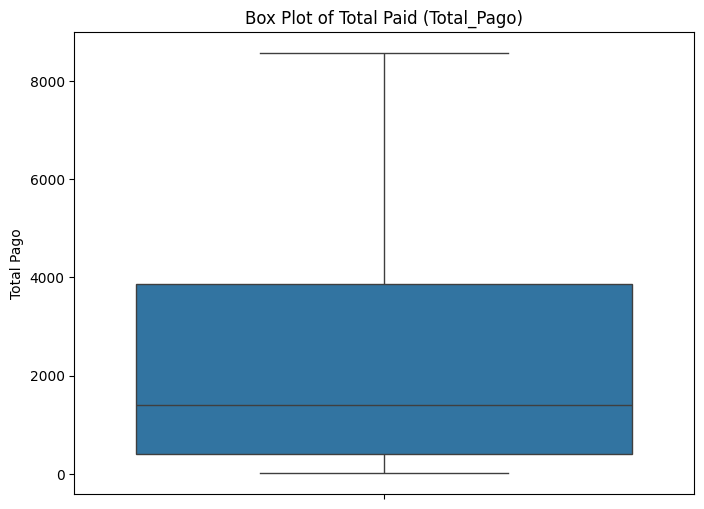

Insight: O box plot confirma a presença de outliers na coluna 'Total_Pago', com pontos bem acima do limite superior.

Outliers em 'Total_Pago' tratados por capping:
  Valores acima de 9064.40 foram limitados a 9064.40
  Valores abaixo de -4794.90 foram limitados a -4794.90


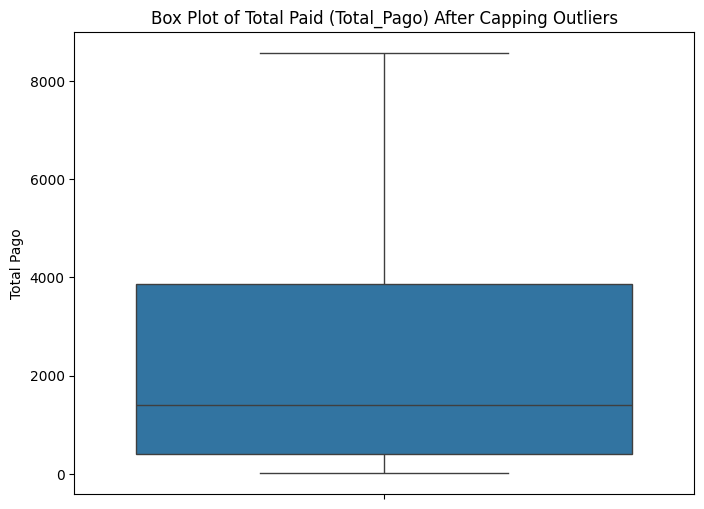

Insight: Após o capping, a distribuição de 'Total_Pago' apresenta menos outliers visíveis, indicando que os valores extremos foram ajustados.


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualize outliers for 'Total_Pago' with a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Total_Pago')
plt.title('Box Plot of Total Paid (Total_Pago)')
plt.ylabel('Total Pago')
plt.show()
print("Insight: O box plot confirma a presença de outliers na coluna 'Total_Pago', com pontos bem acima do limite superior.")

# Treatment of outliers for 'Total_Pago' using IQR method (capping)
Q1 = df['Total_Pago'].quantile(0.25)
Q3 = df['Total_Pago'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Capping outliers
df['Total_Pago'] = np.where(df['Total_Pago'] > upper_bound, upper_bound, df['Total_Pago'])
df['Total_Pago'] = np.where(df['Total_Pago'] < lower_bound, lower_bound, df['Total_Pago'])

print(f"\nOutliers em 'Total_Pago' tratados por capping:")
print(f"  Valores acima de {upper_bound:.2f} foram limitados a {upper_bound:.2f}")
print(f"  Valores abaixo de {lower_bound:.2f} foram limitados a {lower_bound:.2f}")

# Visualize the distribution after capping
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Total_Pago')
plt.title('Box Plot of Total Paid (Total_Pago) After Capping Outliers')
plt.ylabel('Total Pago')
plt.show()
print("Insight: Após o capping, a distribuição de 'Total_Pago' apresenta menos outliers visíveis, indicando que os valores extremos foram ajustados.")


# **4) Realize a etapa da análise bivariada:**

A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.

B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

### Análise Bivariada: Relação com Churn ###



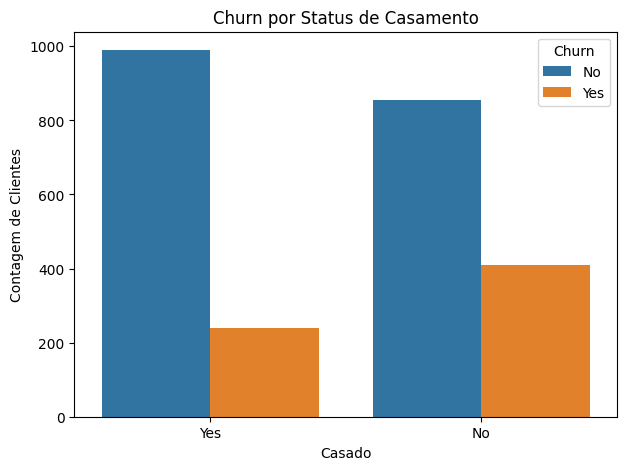

Percentual de Churn por Status de Casamento:


/tmp/ipykernel_2033/2770612754.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(pd.crosstab(df['Casado'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))


Churn,No,Yes
Casado,,
No,67.61%,32.39%
Yes,80.55%,19.45%


Insight: Clientes solteiros (`No`) parecem ter uma taxa de churn ligeiramente maior do que clientes casados (`Yes`).



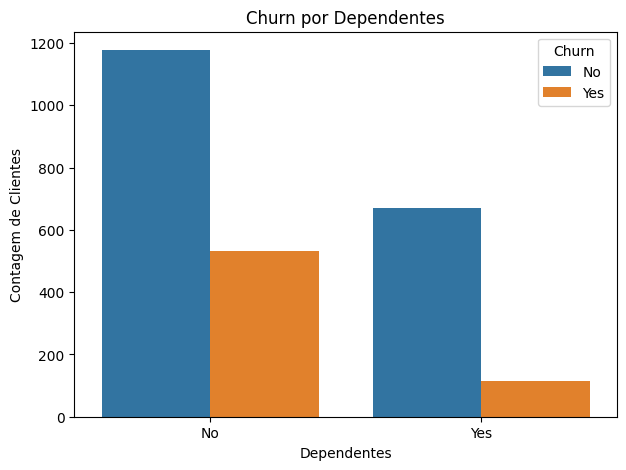

Percentual de Churn por Dependentes:


/tmp/ipykernel_2033/2770612754.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(pd.crosstab(df['Dependents'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))


Churn,No,Yes
Dependents,,
No,68.83%,31.17%
Yes,85.22%,14.78%


Insight: Clientes sem dependentes (`No`) apresentam uma taxa de churn significativamente maior em comparação com aqueles que possuem dependentes (`Yes`).



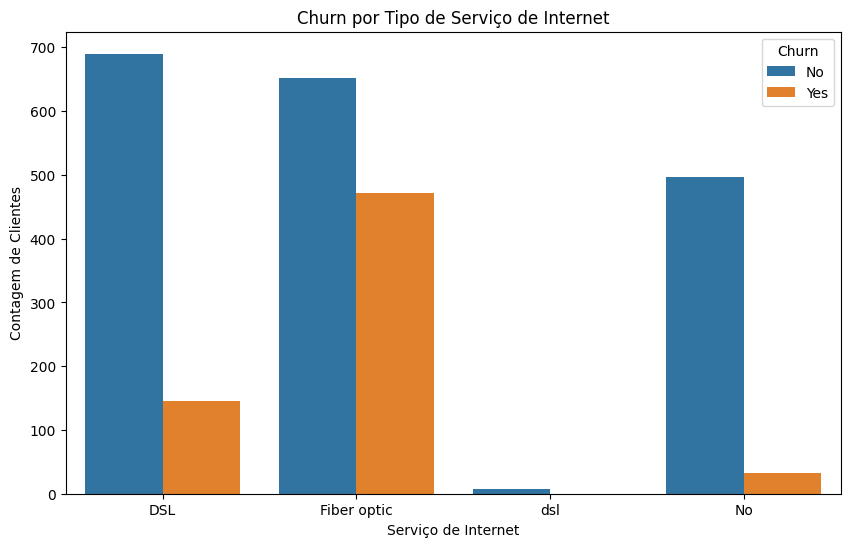

/tmp/ipykernel_2033/2770612754.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(pd.crosstab(df['Servico_Internet'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))


Percentual de Churn por Tipo de Serviço de Internet:


Churn,No,Yes
Servico_Internet,,
DSL,82.63%,17.37%
Fiber optic,58.01%,41.99%
No,93.94%,6.06%
dsl,100.00%,0.00%


Insight: Clientes com 'Fiber optic' (Fibra Óptica) têm uma taxa de churn consideravelmente mais alta, enquanto clientes sem serviço de internet ('No') têm uma taxa de churn muito baixa.



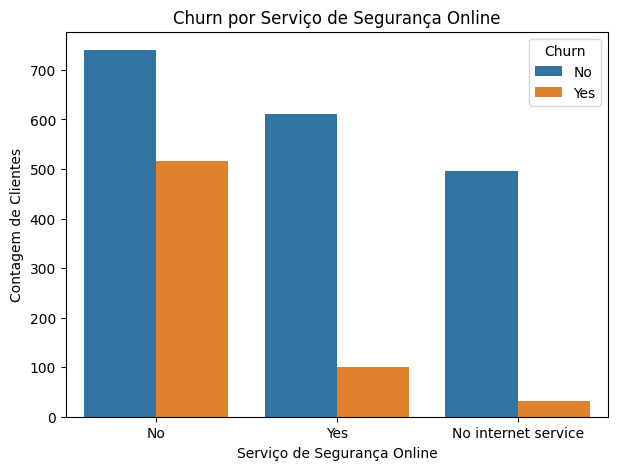

Percentual de Churn por Serviço de Segurança Online:


/tmp/ipykernel_2033/2770612754.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(pd.crosstab(df['Servico_Seguranca'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))


Churn,No,Yes
Servico_Seguranca,,
No,58.87%,41.13%
No internet service,93.94%,6.06%
Yes,85.92%,14.08%


Insight: Clientes sem serviço de segurança online (`No`) tendem a ter uma taxa de churn mais elevada, indicando que este serviço pode ser um fator de retenção.



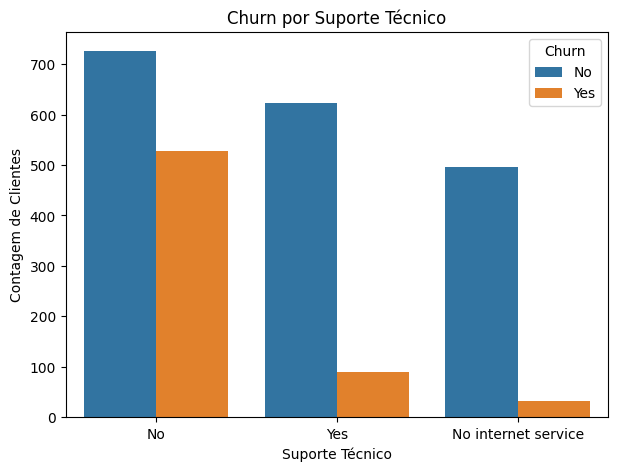

Percentual de Churn por Suporte Técnico:


/tmp/ipykernel_2033/2770612754.py:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(pd.crosstab(df['Suporte_Tecnico'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))


Churn,No,Yes
Suporte_Tecnico,,
No,57.97%,42.03%
No internet service,93.94%,6.06%
Yes,87.38%,12.62%


Insight: Similar ao serviço de segurança, clientes sem suporte técnico (`No`) mostram uma maior propensão ao churn.



In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Análise Bivariada: Relação com Churn ###\n")

# 1. Casado vs Churn
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Casado', hue='Churn')
plt.title('Churn por Status de Casamento')
plt.xlabel('Casado')
plt.ylabel('Contagem de Clientes')
plt.show()
print("Percentual de Churn por Status de Casamento:")
display(pd.crosstab(df['Casado'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))
print("Insight: Clientes solteiros (`No`) parecem ter uma taxa de churn ligeiramente maior do que clientes casados (`Yes`).\n")

# 2. Dependents vs Churn
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title('Churn por Dependentes')
plt.xlabel('Dependentes')
plt.ylabel('Contagem de Clientes')
plt.show()
print("Percentual de Churn por Dependentes:")
display(pd.crosstab(df['Dependents'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))
print("Insight: Clientes sem dependentes (`No`) apresentam uma taxa de churn significativamente maior em comparação com aqueles que possuem dependentes (`Yes`).\n")

# 3. Servico_Internet vs Churn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Servico_Internet', hue='Churn')
plt.title('Churn por Tipo de Serviço de Internet')
plt.xlabel('Serviço de Internet')
plt.ylabel('Contagem de Clientes')
plt.show()
print("Percentual de Churn por Tipo de Serviço de Internet:")
display(pd.crosstab(df['Servico_Internet'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))
print("Insight: Clientes com 'Fiber optic' (Fibra Óptica) têm uma taxa de churn consideravelmente mais alta, enquanto clientes sem serviço de internet ('No') têm uma taxa de churn muito baixa.\n")

# 4. Servico_Seguranca vs Churn
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Servico_Seguranca', hue='Churn')
plt.title('Churn por Serviço de Segurança Online')
plt.xlabel('Serviço de Segurança Online')
plt.ylabel('Contagem de Clientes')
plt.show()
print("Percentual de Churn por Serviço de Segurança Online:")
display(pd.crosstab(df['Servico_Seguranca'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))
print("Insight: Clientes sem serviço de segurança online (`No`) tendem a ter uma taxa de churn mais elevada, indicando que este serviço pode ser um fator de retenção.\n")

# 5. Suporte_Tecnico vs Churn
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Suporte_Tecnico', hue='Churn')
plt.title('Churn por Suporte Técnico')
plt.xlabel('Suporte Técnico')
plt.ylabel('Contagem de Clientes')
plt.show()
print("Percentual de Churn por Suporte Técnico:")
display(pd.crosstab(df['Suporte_Tecnico'], df['Churn'], normalize='index').applymap(lambda x: f'{x:.2%}'))
print("Insight: Similar ao serviço de segurança, clientes sem suporte técnico (`No`) mostram uma maior propensão ao churn.\n")

### Variáveis mais importantes para o Churn

Com base na análise bivariada realizada, as variáveis que parecem ter a maior influência no `Churn` são:

*   **Servico_Internet**: Clientes com `Fiber optic` (Fibra Óptica) apresentam uma taxa de churn significativamente mais alta, enquanto aqueles sem serviço de internet têm uma taxa de churn muito baixa. Isso sugere que a qualidade ou o tipo de serviço de internet é um fator crítico.

*   **Tipo_Contrato**: Clientes com contratos `Month-to-month` (mensais) têm uma propensão muito maior a churn do que aqueles com contratos de `One year` (um ano) ou `Two year` (dois anos). Contratos de longo prazo parecem ser um forte indicador de retenção.

*   **Servico_Seguranca** e **Suporte_Tecnico**: Clientes que não utilizam serviços de segurança online ou suporte técnico (`No`) tendem a ter taxas de churn mais elevadas. Isso indica que esses serviços agregam valor e ajudam na retenção do cliente.

*   **Dependentes**: Clientes sem dependentes (`No`) exibem uma taxa de churn notavelmente maior, o que pode sugerir diferentes necessidades ou lealdade entre esses grupos.